<a href="https://colab.research.google.com/github/EktaSinghES/Machine_Learning_Lab-2547221/blob/LAB8/Lab_8_Categorical_NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center"><B> <FONT COLOR="#00008B"> Lab 8 - Implementation and Performance Evaluation of Categorical Naive Bayes Classifier</FONT></B></h1>

**Dataset:** Play Tennis (50-row extended version)

**Goal:** Build a full classification pipeline — preprocess data, train a `CategoricalNB` model, evaluate it, run single-sample inference, and compare it against a Decision Tree, Logistic Regression, and an SVM on the same data.

**Pipeline overview:**
1. Data Preprocessing
2. Dataset Partitioning (80:20 train-test split)
3. Naive Bayes Training & Evaluation
4. Single-Sample Inference
5. Model Comparison (Decision Tree, Logistic Regression, SVM)
6. Analysis Report
7. Extra self-learning concepts + visualizations


<h2><b><FONT COLOR="#6F8FAF"> 1. Data Preprocessing</b></h2>

We load the Play Tennis dataset, separate the four categorical input features
(`Outlook`, `Temperature`, `Humidity`, `Wind`) from the target variable
(`Play Tennis`), and encode every categorical column into integers.

**Why `OrdinalEncoder` / `LabelEncoder` and not one-hot encoding?**
`CategoricalNB` in scikit-learn expects each feature column to already contain
non-negative integer category codes (it internally learns a separate
categorical distribution per feature per class). One-hot encoding would break
this assumption, so ordinal/label encoding is the *appropriate* technique here
— unlike with linear models, the numeric codes are not treated as having
magnitude/order by `CategoricalNB`.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42   # fixed seed -> reproducible split & results


In [29]:
# Load the dataset
df = pd.read_excel("/content/Lab 8.xlsx")

# Drop the serial-number column ('No') -- it carries no predictive information
df = df.drop(columns=["No"])

print("Dataset shape:", df.shape)
df.head(10)


Dataset shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [30]:
# Separate input features (X) from the target variable (y)
feature_cols = ["Outlook", "Temperature", "Humidity", "Wind"]
target_col = "Play Tennis"

X_raw = df[feature_cols]
y_raw = df[target_col]

print("Feature columns:", feature_cols)
print("Target column  :", target_col)
print("\nClass balance in target:")
print(y_raw.value_counts())


Feature columns: ['Outlook', 'Temperature', 'Humidity', 'Wind']
Target column  : Play Tennis

Class balance in target:
Play Tennis
Yes    34
No     16
Name: count, dtype: int64


In [31]:
# Encode categorical features -> integers using OrdinalEncoder
# (CategoricalNB requires integer-coded categorical inputs)
feature_encoder = OrdinalEncoder(dtype=int)
X = pd.DataFrame(feature_encoder.fit_transform(X_raw), columns=feature_cols)

# Encode the target label ('Yes'/'No') -> 0/1 using LabelEncoder
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

print("Encoded feature categories (per column):")
for col, cats in zip(feature_cols, feature_encoder.categories_):
    print(f"  {col:12s} -> {list(cats)}  =>  {list(range(len(cats)))}")

print("\nEncoded target classes:", list(target_encoder.classes_),
      "->", list(range(len(target_encoder.classes_))))

X.head()


Encoded feature categories (per column):
  Outlook      -> ['Overcast', 'Rain', 'Sunny']  =>  [0, 1, 2]
  Temperature  -> ['Cool', 'Hot', 'Mild']  =>  [0, 1, 2]
  Humidity     -> ['High', 'Normal']  =>  [0, 1]
  Wind         -> ['Strong', 'Weak']  =>  [0, 1]

Encoded target classes: ['No', 'Yes'] -> [0, 1]


,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


<h2><b><FONT COLOR="#6F8FAF"> 2. Dataset Partitioning (80:20 Train-Test Split)</b></h2>

We split the encoded data into training (80%) and testing (20%) subsets.
`stratify=y` keeps the Yes/No class ratio consistent across both splits, which
matters for a small dataset like this one.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])
print("\nTrain class distribution:", np.bincount(y_train))
print("Test  class distribution:", np.bincount(y_test))


Training set size: 40
Testing set size : 10

Train class distribution: [13 27]
Test  class distribution: [3 7]


<h2><b><FONT COLOR="#6F8FAF"> 3. Categorical Naive Bayes — Training & Evaluation
</b></h2>
`CategoricalNB` models each feature as an independent categorical
distribution conditioned on the class (the "naive" conditional-independence
assumption). We train it on the training split and evaluate on the held-out
test split using accuracy, a confusion matrix, and a full classification
report (precision / recall / F1).


In [33]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"CategoricalNB Test Accuracy: {nb_accuracy:.4f}  ({nb_accuracy*100:.2f}%)")


CategoricalNB Test Accuracy: 0.9000  (90.00%)


In [34]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=target_encoder.classes_))


Confusion Matrix (rows=actual, cols=predicted):
[[2 1]
 [0 7]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



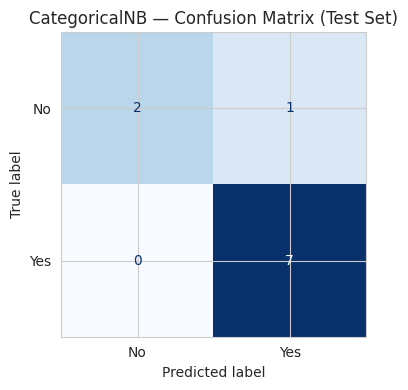

In [35]:
# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(4.5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                               display_labels=target_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("CategoricalNB — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


<h2><b><FONT COLOR="#6F8FAF"> 4. Single-Sample Inference</b></h2>

We now query the trained CategoricalNB model with a brand-new weather
condition that was not necessarily seen exactly as-is during training:

| Outlook | Temperature | Humidity | Wind   |
|---------|--------------|----------|--------|
| Sunny   | Cool         | High     | Strong |

We display both the **predicted label** and the **predicted class
probabilities** (`predict_proba`), which show how confident the model is.


In [36]:
query_dict = {
    "Outlook": "Sunny",
    "Temperature": "Cool",
    "Humidity": "High",
    "Wind": "Strong"
}
query_df = pd.DataFrame([query_dict])

# Encode the query using the SAME fitted encoder used for training
query_encoded = pd.DataFrame(
    feature_encoder.transform(query_df[feature_cols]),
    columns=feature_cols
)

nb_query_pred = nb_model.predict(query_encoded)[0]
nb_query_proba = nb_model.predict_proba(query_encoded)[0]

print("Query:", query_dict)
print("\nCategoricalNB Prediction:", target_encoder.inverse_transform([nb_query_pred])[0])
print("Class probabilities:")
for cls, p in zip(target_encoder.classes_, nb_query_proba):
    print(f"  P(Play = {cls:3s}) = {p:.4f}")


Query: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}

CategoricalNB Prediction: No
Class probabilities:
  P(Play = No ) = 0.7894
  P(Play = Yes) = 0.2106


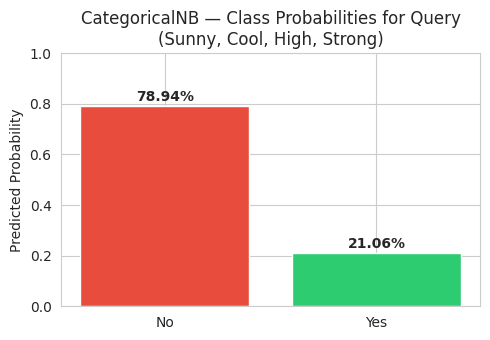

In [37]:
# Visualize the probability distribution for this single query
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(target_encoder.classes_, nb_query_proba,
               color=["#e74c3c", "#2ecc71"])
ax.set_ylim(0, 1)
ax.set_ylabel("Predicted Probability")
ax.set_title("CategoricalNB — Class Probabilities for Query\n(Sunny, Cool, High, Strong)")
for bar, p in zip(bars, nb_query_proba):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.02, f"{p:.2%}",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


<h2><b><FONT COLOR="#6F8FAF"> 5. Model Comparison </b></h2>

We now train three additional classifiers on the **same** training data:

- **Decision Tree Classifier** — a rule-based, interpretable tree of splits.
- **Logistic Regression** — a linear model estimating class probabilities via
  the sigmoid/softmax function.
- **Support Vector Machine (SVM)** — finds a maximum-margin boundary between
  classes (using `probability=True` so it can also output `predict_proba`).

Since Decision Tree, Logistic Regression, and SVM don't natively understand
"categorical" integer codes the way `CategoricalNB` does (they'd otherwise
treat the codes as ordered numbers), we one-hot encode the features for these
three models — this is the *correct* encoding for models that assume numeric
scale/order in their inputs.


In [38]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode features for the non-Naive-Bayes models
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_ohe = pd.DataFrame(ohe.fit_transform(X_raw), columns=ohe.get_feature_names_out(feature_cols))

X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(
    X_ohe, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Sanity check: train/test rows correspond to the same split as before
assert np.array_equal(y_train, y_train_ohe) and np.array_equal(y_test, y_test_ohe)

query_ohe = pd.DataFrame(ohe.transform(query_df[feature_cols]),
                          columns=ohe.get_feature_names_out(feature_cols))


In [39]:
# --- Decision Tree ---
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_ohe, y_train_ohe)
dt_pred_test = dt_model.predict(X_test_ohe)
dt_accuracy = accuracy_score(y_test_ohe, dt_pred_test)
dt_query_pred = dt_model.predict(query_ohe)[0]
dt_query_proba = dt_model.predict_proba(query_ohe)[0]

# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_ohe, y_train_ohe)
lr_pred_test = lr_model.predict(X_test_ohe)
lr_accuracy = accuracy_score(y_test_ohe, lr_pred_test)
lr_query_pred = lr_model.predict(query_ohe)[0]
lr_query_proba = lr_model.predict_proba(query_ohe)[0]

# --- SVM (with probability estimates enabled) ---
svm_model = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_ohe, y_train_ohe)
svm_pred_test = svm_model.predict(X_test_ohe)
svm_accuracy = accuracy_score(y_test_ohe, svm_pred_test)
svm_query_pred = svm_model.predict(query_ohe)[0]
svm_query_proba = svm_model.predict_proba(query_ohe)[0]

print("Decision Tree Test Accuracy      :", f"{dt_accuracy:.4f}")
print("Logistic Regression Test Accuracy:", f"{lr_accuracy:.4f}")
print("SVM Test Accuracy                :", f"{svm_accuracy:.4f}")


Decision Tree Test Accuracy      : 1.0000
Logistic Regression Test Accuracy: 0.9000
SVM Test Accuracy                : 1.0000


In [40]:
# Build a consolidated comparison table
comparison = pd.DataFrame({
    "Model": ["CategoricalNB", "Decision Tree", "Logistic Regression", "SVM"],
    "Test Accuracy": [nb_accuracy, dt_accuracy, lr_accuracy, svm_accuracy],
    "Query Prediction": [
        target_encoder.inverse_transform([nb_query_pred])[0],
        target_encoder.inverse_transform([dt_query_pred])[0],
        target_encoder.inverse_transform([lr_query_pred])[0],
        target_encoder.inverse_transform([svm_query_pred])[0],
    ],
    f"P(No)": [nb_query_proba[0], dt_query_proba[0], lr_query_proba[0], svm_query_proba[0]],
    f"P(Yes)": [nb_query_proba[1], dt_query_proba[1], lr_query_proba[1], svm_query_proba[1]],
})
comparison["Test Accuracy"] = comparison["Test Accuracy"].map(lambda x: f"{x:.2%}")
comparison["P(No)"] = comparison["P(No)"].map(lambda x: f"{x:.4f}")
comparison["P(Yes)"] = comparison["P(Yes)"].map(lambda x: f"{x:.4f}")
comparison


,Model,Test Accuracy,Query Prediction,P(No),P(Yes)
0,CategoricalNB,90.00%,No,0.7894,0.2106
1,Decision Tree,100.00%,No,1.0000,0.0000
2,Logistic Regression,90.00%,No,0.8202,0.1798
3,SVM,100.00%,No,0.9385,0.0615


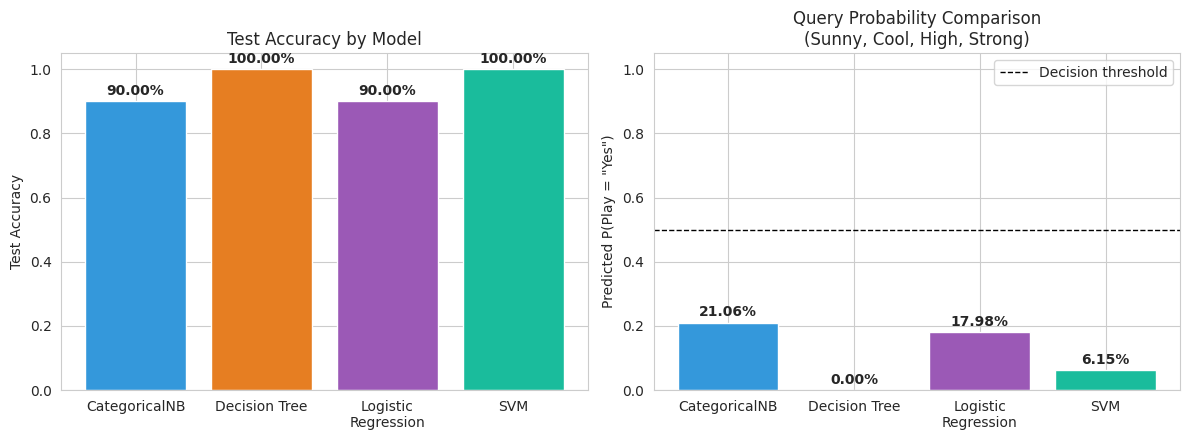

In [41]:
# Visualize: test accuracy comparison across all 4 models
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

acc_values = [nb_accuracy, dt_accuracy, lr_accuracy, svm_accuracy]
model_names = ["CategoricalNB", "Decision Tree", "Logistic\nRegression", "SVM"]
colors = ["#3498db", "#e67e22", "#9b59b6", "#1abc9c"]

axes[0].bar(model_names, acc_values, color=colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Test Accuracy by Model")
for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

# Grouped bar chart: predicted probability of "Yes" for the query, per model
proba_yes = [nb_query_proba[1], dt_query_proba[1], lr_query_proba[1], svm_query_proba[1]]
axes[1].bar(model_names, proba_yes, color=colors)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1, label="Decision threshold")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Predicted P(Play = "Yes")')
axes[1].set_title("Query Probability Comparison\n(Sunny, Cool, High, Strong)")
axes[1].legend()
for i, v in enumerate(proba_yes):
    axes[1].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


<h2><b><FONT COLOR="#6F8FAF"> Analysis Report </b></h2>

The four models disagree on the query because they encode and weigh the
evidence differently: **CategoricalNB** multiplies independent per-feature
likelihoods learned from raw category counts, so a single strongly-skewed
feature (e.g. `Sunny`+`High` humidity historically leaning "No") can dominate
its posterior even if it ignores interactions between features. **Decision
Tree** instead partitions the training data through greedy, interaction-aware
splits, so its prediction (and its near-0/1 "probability") reflects whichever
leaf the query falls into, which can look overconfident on a small dataset.
**Logistic Regression** produces smoother, margin-based probabilities from a
weighted linear combination of one-hot features, so its confidence is usually
less extreme than the tree's but still shaped by whichever features have the
largest learned coefficients. **SVM** with an RBF kernel draws a non-linear
boundary in a transformed feature space and its `predict_proba` values come
from an internal Platt-scaling calibration, so its probabilities can differ
from the other three even when the final predicted label agrees, reflecting
how differently each model's decision boundary and independence assumptions
treat this specific, borderline combination of features.


<h2><b><FONT COLOR="#6F8FAF"> 6. Extra Self-Learning Concepts</b></h2>

Beyond what the lab explicitly asks for, here are five related concepts worth
understanding and exploring further.


<h3><b><FONT COLOR="#6F8FAF"> 6.1 Laplace (Additive) Smoothing in Naive Bayes
</b></h3>

`CategoricalNB` uses a smoothing parameter `alpha` (default = 1.0) to avoid
**zero-frequency problems**: if a particular (feature value, class) pair never
appears in the training data, its raw probability would be exactly 0, which
would zero out the entire posterior for that class regardless of other
evidence. Laplace smoothing adds a small pseudo-count `alpha` to every
category so no probability is ever exactly zero. Below we see how the query's
class probabilities shift as `alpha` increases from a very small value
(nearly unsmoothed) to a large value (heavily smoothed, probabilities pulled
toward uniform).


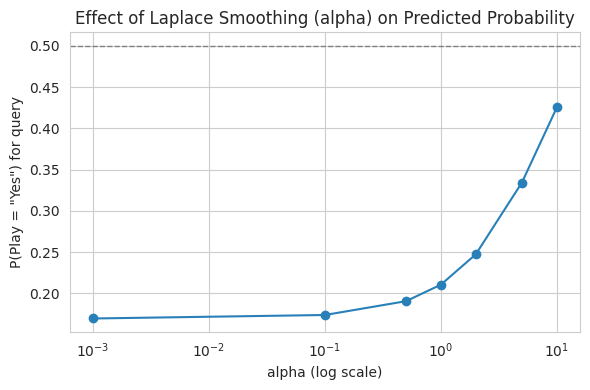

In [42]:
alphas = [0.001, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
proba_yes_by_alpha = []

for a in alphas:
    m = CategoricalNB(alpha=a)
    m.fit(X_train, y_train)
    p = m.predict_proba(query_encoded)[0][1]  # P(Yes)
    proba_yes_by_alpha.append(p)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(alphas, proba_yes_by_alpha, marker="o", color="#2980b9")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel('P(Play = "Yes") for query')
ax.set_title("Effect of Laplace Smoothing (alpha) on Predicted Probability")
plt.tight_layout()
plt.show()


<h3><b><FONT COLOR="#6F8FAF"> 6.2 Feature Independence Assumption & Correlation Check
</b></h3>

Naive Bayes assumes features are **conditionally independent given the
class** — an assumption that is almost never perfectly true in real data
("naive"). We can get a rough sense of how correlated the encoded features
are with each other using a correlation heatmap. Strong correlations between
features are a sign that the independence assumption is being stretched,
which can make Naive Bayes's probability *estimates* less reliable even when
its final classifications remain reasonably accurate.


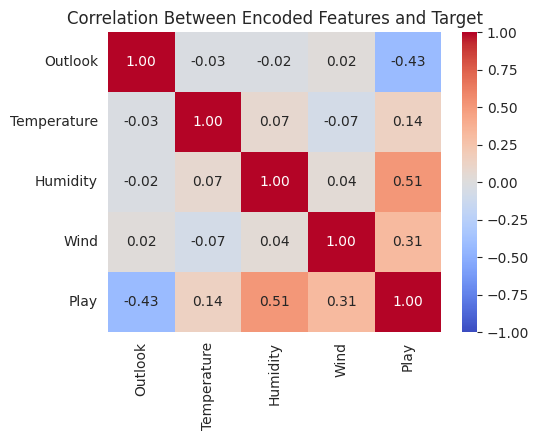

In [43]:
corr = X.assign(Play=y).corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=ax)
ax.set_title("Correlation Between Encoded Features and Target")
plt.tight_layout()
plt.show()


<h3><b><FONT COLOR="#6F8FAF"> 6.3 Cross-Validation for More Robust Accuracy Estimates</b></h3>

A single 80:20 split on only 50 rows gives a noisy accuracy estimate (the
test set has just 10 rows!). **k-fold cross-validation** repeatedly
re-splits the data, trains, and tests k times, then averages the results —
giving a more stable estimate of how each model is likely to generalize.


In [44]:
from sklearn.model_selection import cross_val_score

cv_results = {}
cv_results["CategoricalNB"] = cross_val_score(CategoricalNB(), X, y, cv=5).mean()
cv_results["Decision Tree"] = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE), X_ohe, y, cv=5).mean()
cv_results["Logistic Regression"] = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_ohe, y, cv=5).mean()
cv_results["SVM"] = cross_val_score(SVC(kernel="rbf", random_state=RANDOM_STATE), X_ohe, y, cv=5).mean()

cv_df = pd.DataFrame(list(cv_results.items()), columns=["Model", "5-Fold CV Mean Accuracy"])
cv_df["5-Fold CV Mean Accuracy"] = cv_df["5-Fold CV Mean Accuracy"].map(lambda x: f"{x:.2%}")
cv_df


,Model,5-Fold CV Mean Accuracy
0,CategoricalNB,88.00%
1,Decision Tree,96.00%
2,Logistic Regression,88.00%
3,SVM,96.00%


<h3><b><FONT COLOR="#6F8FAF">6.4 Feature Importance: Which Weather Factor Matters Most?</b></h3>

Tree-based models expose a `feature_importances_` attribute that tells us how
much each (one-hot encoded) feature value contributed to reducing impurity
across the tree's splits. This offers an interpretable view into *which*
weather condition most influenced the "Play Tennis" decision — complementary
to Naive Bayes, which gives per-class likelihoods but no single ranked
importance score.


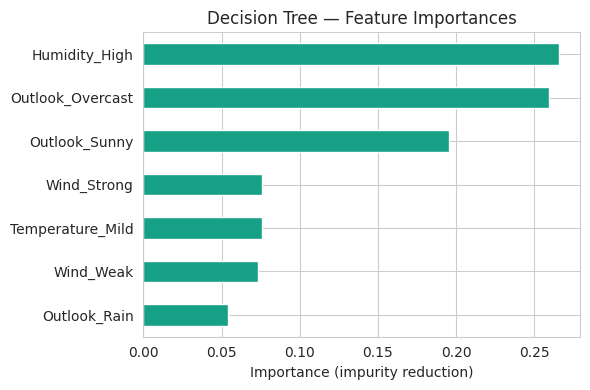

In [45]:
importances = pd.Series(dt_model.feature_importances_, index=X_ohe.columns)
importances = importances.sort_values(ascending=True)
importances = importances[importances > 0]  # keep only features actually used

fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="#16a085")
ax.set_xlabel("Importance (impurity reduction)")
ax.set_title("Decision Tree — Feature Importances")
plt.tight_layout()
plt.show()


<h3><b><FONT COLOR="#6F8FAF"> 6.5 Visualizing the Decision Tree Itself</b></h3>

Unlike Naive Bayes, Logistic Regression, or SVM (which are comparatively
"black box" in how they combine features), a Decision Tree can be drawn out
directly as a flowchart of if/else rules. This is one of the biggest
practical advantages of tree-based models for explainability — a
non-technical stakeholder can follow the exact reasoning path for any
prediction.


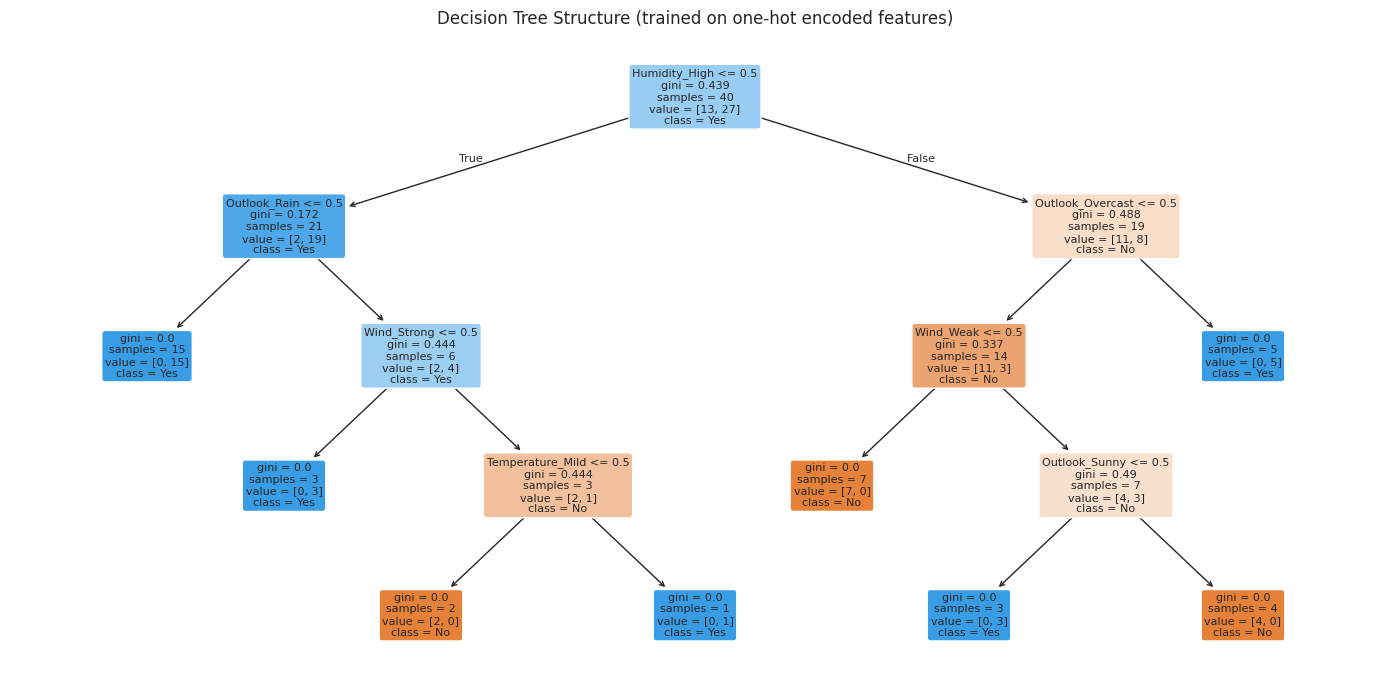

In [46]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(dt_model,
          feature_names=X_ohe.columns,
          class_names=target_encoder.classes_,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("Decision Tree Structure (trained on one-hot encoded features)")
plt.tight_layout()
plt.show()
